# Download and preprocess all public daily snow station data into Zarr format

Data source: [egagli/global_snow_networks](https://github.com/egagli/global_snow_networks) — a daily-refreshed archive of daily snow point observations from multiple public networks (SNOTEL, SNOTEL Lite, CCSS/CDEC, BC Snow Survey, NVE Norway, SCAN, COOP, and AWDB's "MSNT" bucket).

Two files:
- [`all_daily_snow_stations.geojson`](https://github.com/egagli/global_snow_networks/blob/main/all_daily_snow_stations.geojson) — merged daily-only station inventory (metadata)
- [`data/all_station_csvs.tar.xz`](https://github.com/egagli/global_snow_networks/blob/main/data/all_station_csvs.tar.xz) — one CSV per station (`date, wteq_cm, snwd_cm`)

This notebook downloads both, extracts the CSVs, combines everything into a single `(time, station_id)` xarray Dataset, and writes it to Zarr.

**Units:** SWE is converted from cm to **mm** (kg m⁻²) to match the NorSWE `snw` convention used in `../compare_to_NorSWE`, so the downstream comparison notebooks are unit-identical. Snow depth stays in cm.

In [13]:
import requests
import tarfile
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import easysnowdata
import matplotlib.pyplot as plt
import contextily as ctx

data_dir = Path("data/snow_pillows")
data_dir.mkdir(parents=True, exist_ok=True)

geojson_filename = "all_daily_snow_stations.geojson"
geojson_filepath = data_dir / geojson_filename

tar_filename = "all_station_csvs.tar.xz"
tar_filepath = data_dir / tar_filename
csv_dir = data_dir / "stations"

zarr_filepath = data_dir / "snow_pillows.zarr"

base_url = "https://raw.githubusercontent.com/egagli/global_snow_networks/main"

In [14]:
# Get station inventory + CSV bundle (~30 MB total, skipped if already present).
# NOTE: the source repo is currently private, so anonymous raw.githubusercontent.com
# requests 404. Prefer a local clone if one exists; otherwise authenticate the
# download with a GitHub token from the GITHUB_TOKEN environment variable.
import os

local_repo_dir = Path.home() / "repos/global_snow_networks"

headers = {}
if os.environ.get("GITHUB_TOKEN"):
    headers["Authorization"] = f"token {os.environ['GITHUB_TOKEN']}"

for remote_path, filepath in [(geojson_filename, geojson_filepath),
                              (f"data/{tar_filename}", tar_filepath)]:
    if filepath.exists():
        print(f"{filepath} already exists")
        continue

    local_file = local_repo_dir / remote_path
    if local_file.exists():
        shutil.copy(local_file, filepath)
        print(f"Copied from local clone -> {filepath} ({filepath.stat().st_size / 1e6:.1f} MB)")
        continue

    print(f"Downloading {remote_path}...")
    with requests.get(f"{base_url}/{remote_path}", stream=True, headers=headers) as r:
        r.raise_for_status()
        with open(filepath, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
    print(f"Downloaded -> {filepath} ({filepath.stat().st_size / 1e6:.1f} MB)")

data/snow_pillows/all_daily_snow_stations.geojson already exists
data/snow_pillows/all_station_csvs.tar.xz already exists


In [15]:
# Extract CSVs (tarball contains stations/*.csv)
if not csv_dir.exists() or not any(csv_dir.glob("*.csv")):
    print("Extracting...")
    with tarfile.open(tar_filepath, 'r:xz') as tf:
        tf.extractall(data_dir)
    print("Extraction complete")
else:
    print("Already extracted")

csv_files = sorted(csv_dir.glob("*.csv"))
print(f"{len(csv_files)} station CSVs")

Already extracted
1522 station CSVs


In [16]:
stations_gdf = gpd.read_file(geojson_filepath)
csv_codes = {f.stem for f in csv_files}
print(f"{len(stations_gdf)} stations in inventory, {stations_gdf['code'].isin(csv_codes).sum()} with CSVs")
stations_gdf['networkCode'].value_counts()

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'drainage_basin_key' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


1945 stations in inventory, 1522 with CSVs


networkCode
SNTL     923
CCSS     557
MSNT     180
BCSS     151
SNTLT     53
NVE       31
SCAN      26
COOP      24
Name: count, dtype: int64

## Combine all station CSVs into a single (time, station_id) Dataset

Read every CSV, then fill two preallocated `(time, station_id)` float32 arrays by positional date index (much faster than pandas alignment across 1500+ misaligned series).

A few hundred CSVs contain a single corrupted date row (truncated strings, a refresh artifact in the source repo) — those rows are coerced to NaT and dropped.

In [17]:
%%time
frames = {}
n_bad_dates = 0
for f in csv_files:
    df = pd.read_csv(f)
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
    n_bad_dates += int(df['date'].isna().sum())
    df = df.dropna(subset=['date']).drop_duplicates(subset='date', keep='first').set_index('date')
    frames[f.stem] = df

print(f"Read {len(frames)} CSVs, dropped {n_bad_dates} rows with corrupted dates")

Read 1522 CSVs, dropped 207 rows with corrupted dates
CPU times: user 14.9 s, sys: 292 ms, total: 15.2 s
Wall time: 16.2 s


In [18]:
%%time
tmin = min(df.index.min() for df in frames.values())
tmax = max(df.index.max() for df in frames.values())
full_index = pd.date_range(tmin, tmax, freq='D')
print(f"time range {tmin.date()} .. {tmax.date()} ({len(full_index)} days)")

station_ids = np.array(list(frames.keys()))
swe = np.full((len(full_index), len(station_ids)), np.nan, dtype='float32')
snow_depth = np.full_like(swe, np.nan)
for j, sid in enumerate(station_ids):
    df = frames[sid]
    pos = (df.index - tmin).days.values
    swe[pos, j] = df['wteq_cm'].values * 10.0   # cm -> mm (kg m-2), matches NorSWE 'snw'
    snow_depth[pos, j] = df['snwd_cm'].values   # keep cm

meta = stations_gdf.set_index('code').reindex(station_ids)
assert meta['name'].notna().all(), "CSV without matching inventory entry"

# .to_numpy(dtype=...) rather than .values: pandas 3 string columns are Arrow-backed,
# and .values/.astype(str) return an ArrowStringArray whose StringDtype dask can't chunk
snow_pillows_ds = xr.Dataset(
    {
        'swe':        (('time', 'station_id'), swe),
        'snow_depth': (('time', 'station_id'), snow_depth),
    },
    coords={
        'time':         full_index,
        'station_id':   station_ids.astype(str),
        'station_name': ('station_id', meta['name'].to_numpy(dtype=str)),
        'network':      ('station_id', meta['networkCode'].to_numpy(dtype=str)),
        'client':       ('station_id', meta['client'].to_numpy(dtype=str)),
        'state':        ('station_id', meta['state'].fillna('').to_numpy(dtype=str)),
        'latitude':     ('station_id', meta['latitude'].to_numpy('float64')),
        'longitude':    ('station_id', meta['longitude'].to_numpy('float64')),
        'elevation':    ('station_id', meta['elevation_m'].to_numpy('float32')),
    },
)
snow_pillows_ds['swe'].attrs = {'units': 'mm', 'long_name': 'snow water equivalent'}
snow_pillows_ds['snow_depth'].attrs = {'units': 'cm', 'long_name': 'snow depth'}
snow_pillows_ds['elevation'].attrs = {'units': 'm'}
snow_pillows_ds.attrs['source_url'] = 'https://github.com/egagli/global_snow_networks'
snow_pillows_ds.attrs['description'] = ('Daily SWE and snow depth from public snow networks '
                                        '(SNOTEL, SNOTEL Lite, CCSS/CDEC, BC Snow Survey, NVE, SCAN, COOP, MSNT)')
snow_pillows_ds

time range 1896-12-01 .. 2026-07-05 (47333 days)
CPU times: user 1.2 s, sys: 570 ms, total: 1.77 s
Wall time: 1.79 s


<xarray.Dataset> Size: 577MB
Dimensions:       (time: 47333, station_id: 1522)
Coordinates:
  * time          (time) datetime64[us] 379kB 1896-12-01 ... 2026-07-05
  * station_id    (station_id) <U16 97kB '0280_AK_COOP' ... 'WWC_CA_MSNT'
    station_name  (station_id) <U36 219kB 'Anchorage Wscmo AP' ... 'West Wood...
    network       (station_id) <U5 30kB 'COOP' 'COOP' 'MSNT' ... 'CCSS' 'MSNT'
    client        (station_id) <U6 37kB 'awdb' 'awdb' 'awdb' ... 'cdec' 'awdb'
    state         (station_id) <U2 12kB 'AK' 'AK' 'AB' 'AB' ... 'CA' 'CA' 'CA'
    latitude      (station_id) float64 12kB 61.17 71.29 49.36 ... 37.03 37.03
    longitude     (station_id) float64 12kB -150.0 -156.7 ... -118.9 -118.9
    elevation     (station_id) float32 6kB 36.6 6.1 ... 2.774e+03 2.774e+03
Data variables:
    swe           (time, station_id) float32 288MB nan nan nan ... nan nan nan
    snow_depth    (time, station_id) float32 288MB nan nan nan ... nan nan nan
Attributes:
    source_url:   https://github.com/egagli/global_snow_networks
    description:  Daily SWE and snow depth from public snow networks (SNOTEL,...

In [19]:
# how much memory does the dataset take up in RAM when loaded?
print(f"Estimated RAM usage when loaded: {snow_pillows_ds.nbytes / 1e9:.2f} GB")

Estimated RAM usage when loaded: 0.58 GB


In [20]:
if zarr_filepath.exists():
    shutil.rmtree(zarr_filepath)
    print(f'{zarr_filepath} already exists, deleted for fresh conversion')

snow_pillows_ds.chunk({'time': 4000, 'station_id': -1}).to_zarr(zarr_filepath, mode='w')

zarr_size_mb = sum(f.stat().st_size for f in zarr_filepath.rglob("*") if f.is_file()) / 1e6
print(f"Zarr size on disk: {zarr_size_mb:.1f} MB")

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=16, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with thi

Zarr size on disk: 26.9 MB


## Confirm Zarr version of the dataset is complete and remove the tarball + extracted CSVs

In [21]:
snow_pillows_ds = xr.open_zarr(zarr_filepath)
snow_pillows_ds

<xarray.Dataset> Size: 577MB
Dimensions:       (time: 47333, station_id: 1522)
Coordinates:
  * time          (time) datetime64[ns] 379kB 1896-12-01 ... 2026-07-05
  * station_id    (station_id) <U16 97kB '0280_AK_COOP' ... 'WWC_CA_MSNT'
    client        (station_id) <U6 37kB dask.array<chunksize=(1522,), meta=np.ndarray>
    elevation     (station_id) float32 6kB dask.array<chunksize=(1522,), meta=np.ndarray>
    latitude      (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    longitude     (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    network       (station_id) <U5 30kB dask.array<chunksize=(1522,), meta=np.ndarray>
    state         (station_id) <U2 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    station_name  (station_id) <U36 219kB dask.array<chunksize=(1522,), meta=np.ndarray>
Data variables:
    snow_depth    (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
    swe           (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
Attributes:
    source_url:   https://github.com/egagli/global_snow_networks
    description:  Daily SWE and snow depth from public snow networks (SNOTEL,...

In [22]:
if csv_dir.exists():
    shutil.rmtree(csv_dir)
    print(f'{csv_dir} deleted to save space')
if tar_filepath.exists():
    tar_filepath.unlink()
    print(f'{tar_filepath} deleted to save space')

data/snow_pillows/stations deleted to save space
data/snow_pillows/all_station_csvs.tar.xz deleted to save space


## Inspect distribution of sites

In [23]:
snow_pillows_gdf = gpd.GeoDataFrame(
    {
        'station_id':   snow_pillows_ds['station_id'].values,
        'station_name': snow_pillows_ds['station_name'].values,
        'network':      snow_pillows_ds['network'].values,
        'client':       snow_pillows_ds['client'].values,
        'state':        snow_pillows_ds['state'].values,
        'elevation':    snow_pillows_ds['elevation'].values,
    },
    geometry=gpd.points_from_xy(snow_pillows_ds['longitude'].values, snow_pillows_ds['latitude'].values),
    crs='EPSG:4326',
)

snow_pillows_gdf

,station_id,station_name,network,client,state,elevation,geometry
0,0280_AK_COOP,Anchorage Wscmo AP,COOP,awdb,AK,36.599998,POINT (-150.02771 61.16916)
1,0546_AK_COOP,Barrow WSO Airport,COOP,awdb,AK,6.100000,POINT (-156.73938 71.28703)
2,05AA809_AB_MSNT,Gardiner Creek,MSNT,awdb,AB,1969.900024,POINT (-114.5158 49.3611)
3,05AA817_AB_MSNT,South Racehorse Creek,MSNT,awdb,AB,1919.900024,POINT (-114.6 49.78333)
4,05AD803_AB_MSNT,Akima Pass #2,MSNT,awdb,AB,1760.800049,POINT (-114.05294 49.02728)
...,...,...,...,...,...,...,...
1517,WHW_CA_MSNT,White Wolf,MSNT,awdb,CA,2444.500000,POINT (-119.652 37.859)
1518,WTM,WET MEADOWS,CCSS,cdec,CA,2755.100098,POINT (-118.57167 36.34963)
1519,WTM_CA_MSNT,Wet Meadows,MSNT,awdb,CA,2721.899902,POINT (-118.572 36.348)
1520,WWC,WEST WOODCHUCK MEADOW,CCSS,cdec,CA,2773.699951,POINT (-118.91478 37.03103)


In [24]:
snow_pillows_gdf.explore(
    column='network',
    tooltip=['station_id', 'station_name', 'network', 'client', 'state', 'elevation'],
    marker_kwds={'radius': 4},
)

## Sanity check: compare against the easysnowdata SNOTEL archive for the same site (Paradise, WA)

In [25]:
StationsWUS = easysnowdata.automatic_weather_stations.StationCollection()
StationsWUS.get_entire_data_archive()
paradise_easysnowdata_swe_mm_da = 1000.0 * StationsWUS.entire_data_archive['WTEQ'].sel(station="679_WA_SNTL")  # m -> mm
paradise_pillow_swe_da = snow_pillows_ds['swe'].sel(station_id='679_WA_SNTL')

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/easysnowdata/automatic_weather_stations.py:377: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.concat(datasets, dim="station", coords="all")


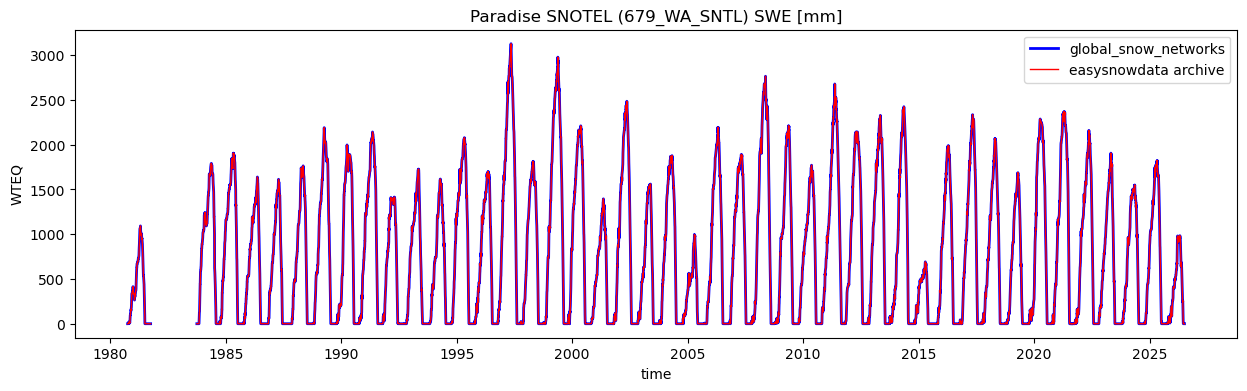

In [26]:
f, ax = plt.subplots(figsize=(15, 4))
paradise_pillow_swe_da.plot(ax=ax, label='global_snow_networks', color='blue', zorder=1, linewidth=2)
paradise_easysnowdata_swe_mm_da.plot(ax=ax, label='easysnowdata archive', color='red', zorder=2, linewidth=1)
ax.set_title('Paradise SNOTEL (679_WA_SNTL) SWE [mm]')
ax.legend()

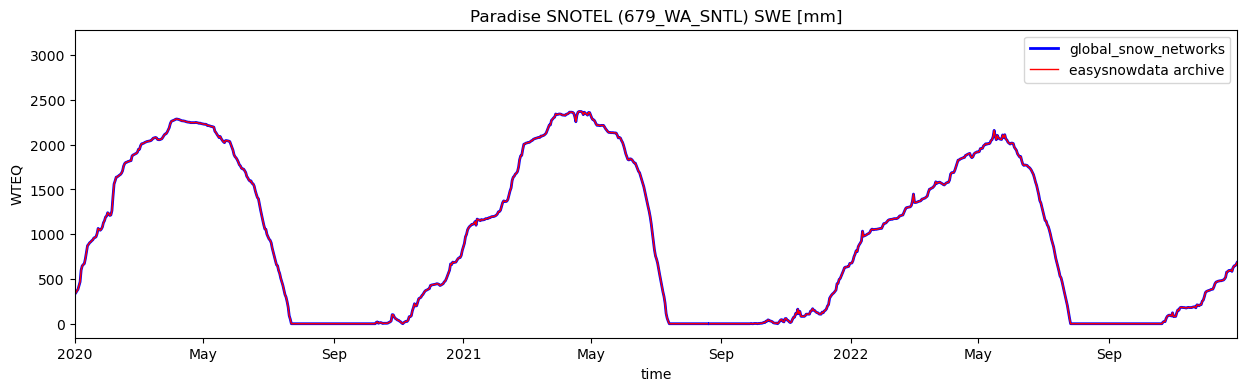

: 

In [ ]:
f, ax = plt.subplots(figsize=(15, 4))
paradise_pillow_swe_da.plot(ax=ax, label='global_snow_networks', color='blue', zorder=1, linewidth=2)
paradise_easysnowdata_swe_mm_da.plot(ax=ax, label='easysnowdata archive', color='red', zorder=2, linewidth=1)
ax.set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2022-12-31')])
ax.set_title('Paradise SNOTEL (679_WA_SNTL) SWE [mm]')
ax.legend()